# Student Dropout Prediction
**Problem statement:** Predict whether a student is at risk of dropping out so institutions can offer early support.
**Target variable:** Dropout_Risk (1 = Dropout, 0 = Enrolled/Graduate)
**Input features:** Academic (semester grades, approved units), demographic (age, gender, marital status), socioeconomic (scholarship, debtor, tuition status, parents' background), enrollment (course, application mode, attendance).
**Real-world application:** An early-warning system where advisors flag high-risk students for tutoring, counselling or financial aid.

In [1]:
!pip install -q streamlit joblib

import warnings
warnings.filterwarnings("ignore")

import os, json, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 81.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 100.3 MB/s eta 0:00:00


In [2]:
from google.colab import files

if not os.path.exists("dataset.csv"):
    uploaded = files.upload()          # choose your dataset CSV
    os.rename(list(uploaded.keys())[0], "dataset.csv")

df = pd.read_csv("dataset.csv", sep=None, engine="python")   # auto-detects , or ;
df.columns = df.columns.str.strip()
df = df.rename(columns={"Nationality": "Nacionality"})       # keep one consistent name

df.head()

Saving dataset.csv to dataset.csv


,﻿Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [3]:
preview = df[['Gender', 'Age at enrollment', 'Course', 'Scholarship holder',
              'Curricular units 1st sem (grade)',
              'Curricular units 2nd sem (grade)', 'Target']].head()
preview.columns = ['Gender', 'Age', 'Course', 'Scholarship',
                   '1st Sem Grade', '2nd Sem Grade', 'Target']
display(preview)

print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nData types:\n", df.dtypes.value_counts())
print("\nTarget distribution:\n", df["Target"].value_counts())

,Gender,Age,Course,Scholarship,1st Sem Grade,2nd Sem Grade,Target
0,1,20,2,0,0.000000,0.000000,Dropout
1,1,19,11,0,14.000000,13.666667,Graduate
2,1,19,5,0,0.000000,0.000000,Dropout
3,0,20,15,0,13.428571,12.400000,Graduate
4,0,45,3,0,12.333333,13.000000,Graduate


Shape: (4424, 35)

Columns:
 ['\ufeffMarital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP', 'Target']

Data types:
 int64      29
flo

In [4]:
# Missing values
missing = df.isnull().sum()
print("Total missing values:", missing.sum())
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found ✅")

# Duplicates
dups = df.duplicated().sum()
print("\nDuplicate rows:", dups)
df = df.drop_duplicates().reset_index(drop=True)

# Binary target: 1 = Dropout, 0 = Enrolled/Graduate
df["Dropout_Risk"] = (df["Target"] == "Dropout").astype(int)

print("\nBinary target counts:")
print(df["Dropout_Risk"].value_counts())
print((df["Dropout_Risk"].value_counts(normalize=True) * 100).round(1).astype(str) + " %")

Total missing values: 0
No missing values found ✅

Duplicate rows: 0

Binary target counts:
Dropout_Risk
0    3003
1    1421
Name: count, dtype: int64
Dropout_Risk
0    67.9 %
1    32.1 %
Name: proportion, dtype: object


In [5]:
import re

assert "df" in globals(), "❌ 'df' not found. Run Cell 2 (load dataset) first."

categorical_cols = [
    'Marital status', 'Application mode', 'Course',
    'Daytime/evening attendance', 'Previous qualification', 'Nacionality',
    "Mother's qualification", "Father's qualification",
    "Mother's occupation", "Father's occupation",
    'Displaced', 'Educational special needs', 'Debtor',
    'Tuition fees up to date', 'Gender', 'Scholarship holder', 'International'
]

other_cols = ['Target', 'Application order', 'Age at enrollment',
              'Unemployment rate', 'Inflation rate', 'GDP']
for sem in ("1st", "2nd"):
    for part in ("credited", "enrolled", "evaluations", "approved", "grade", "without evaluations"):
        other_cols.append(f"Curricular units {sem} sem ({part})")

def norm(s):
    s = re.sub(r"[^a-z0-9]", "", str(s).lower())
    return s.replace("nationality", "nacionality")

canonical = {norm(c): c for c in categorical_cols + other_cols}
df = df.rename(columns={c: canonical[norm(c)] for c in df.columns if norm(c) in canonical})

missing_cols = [c for c in categorical_cols + ["Target"] if c not in df.columns]
if missing_cols:
    print("❌ Still missing:", missing_cols)
    print("\nYour dataset's columns are:\n", df.columns.tolist())
    raise SystemExit("Send me this list and I'll fix it.")

df["Dropout_Risk"] = (df["Target"].astype(str).str.strip().str.lower() == "dropout").astype(int)
print("Target values found:", df["Target"].unique().tolist())
print("Dropout_Risk counts:\n", df["Dropout_Risk"].value_counts(), "\n")
assert df["Dropout_Risk"].nunique() == 2, "❌ Only one class found; check the Target column values."

X = df.drop(columns=["Target", "Dropout_Risk"])
y = df["Dropout_Risk"]

numerical_cols = [c for c in X.columns if c not in categorical_cols]
print("Categorical features:", len(categorical_cols))
print("Numerical features  :", len(numerical_cols))

non_numeric = [c for c in categorical_cols if not pd.api.types.is_numeric_dtype(X[c])]
if non_numeric:
    print("\n⚠️ These categorical columns are text, not numeric codes:", non_numeric)

X_preview = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
print("\nEncoded dataset shape:", X_preview.shape)
display(X_preview.head())

Target values found: ['Dropout', 'Graduate', 'Enrolled']
Dropout_Risk counts:
 Dropout_Risk
0    3003
1    1421
Name: count, dtype: int64 

Categorical features: 17
Numerical features  : 17

Encoded dataset shape: (4424, 236)


,Application order,Age at enrollment,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),...,Father's occupation_44,Father's occupation_45,Father's occupation_46,Displaced_1,Educational special needs_1,Debtor_1,Tuition fees up to date_1,Gender_1,Scholarship holder_1,International_1
0,5,20,0,0,0,0,0.000000,0,0,0,...,False,False,False,True,False,False,True,True,False,False
1,1,19,0,6,6,6,14.000000,0,0,6,...,False,False,False,True,False,False,False,True,False,False
2,5,19,0,6,0,0,0.000000,0,0,6,...,False,False,False,True,False,False,False,True,False,False
3,2,20,0,6,8,6,13.428571,0,0,6,...,False,False,False,True,False,False,True,False,False,False
4,1,45,0,6,9,5,12.333333,0,0,6,...,False,False,False,False,False,False,True,False,False,False


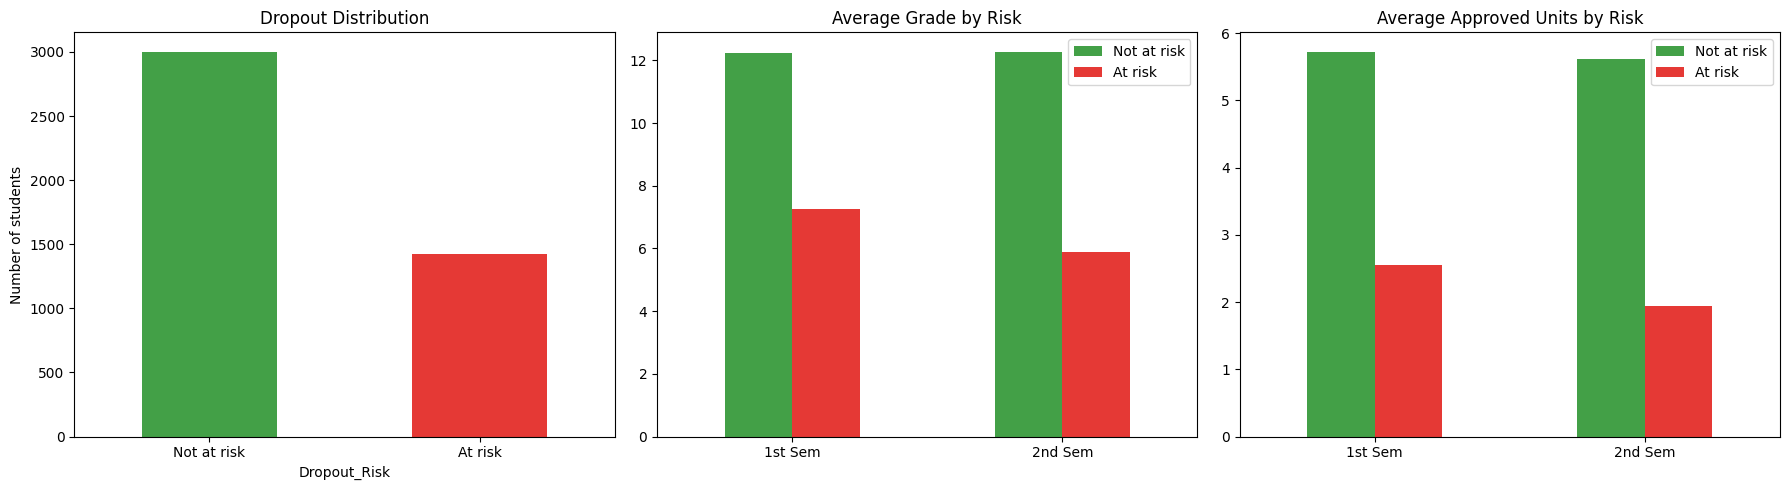

In [6]:
g1, g2 = 'Curricular units 1st sem (grade)', 'Curricular units 2nd sem (grade)'
a1, a2 = 'Curricular units 1st sem (approved)', 'Curricular units 2nd sem (approved)'
colors = ["#43a047", "#e53935"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df["Dropout_Risk"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color=colors)
axes[0].set_title("Dropout Distribution")
axes[0].set_xticklabels(["Not at risk", "At risk"], rotation=0)
axes[0].set_ylabel("Number of students")

df.groupby("Dropout_Risk")[[g1, g2]].mean().T.plot(kind="bar", ax=axes[1], color=colors)
axes[1].set_title("Average Grade by Risk")
axes[1].set_xticklabels(["1st Sem", "2nd Sem"], rotation=0)
axes[1].legend(["Not at risk", "At risk"])

df.groupby("Dropout_Risk")[[a1, a2]].mean().T.plot(kind="bar", ax=axes[2], color=colors)
axes[2].set_title("Average Approved Units by Risk")
axes[2].set_xticklabels(["1st Sem", "2nd Sem"], rotation=0)
axes[2].legend(["Not at risk", "At risk"])

plt.tight_layout()
plt.show()

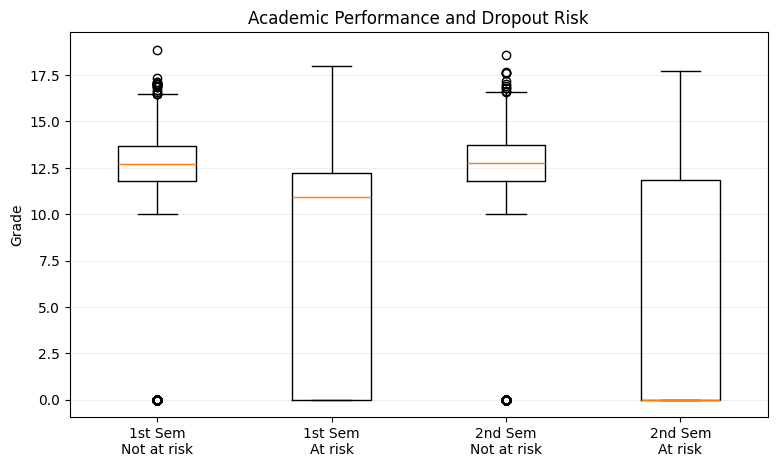

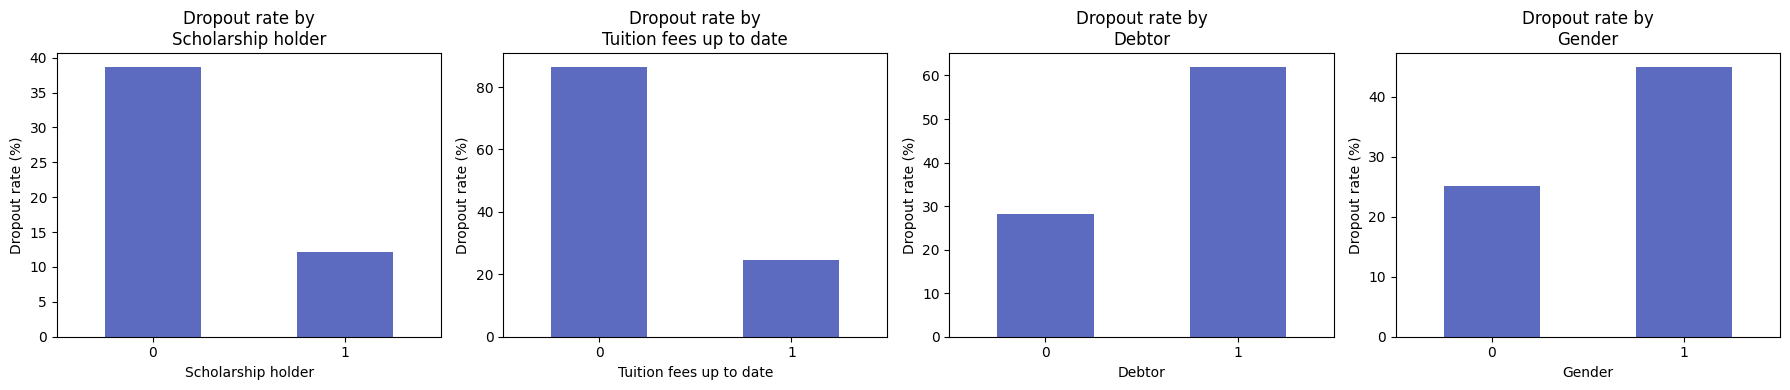

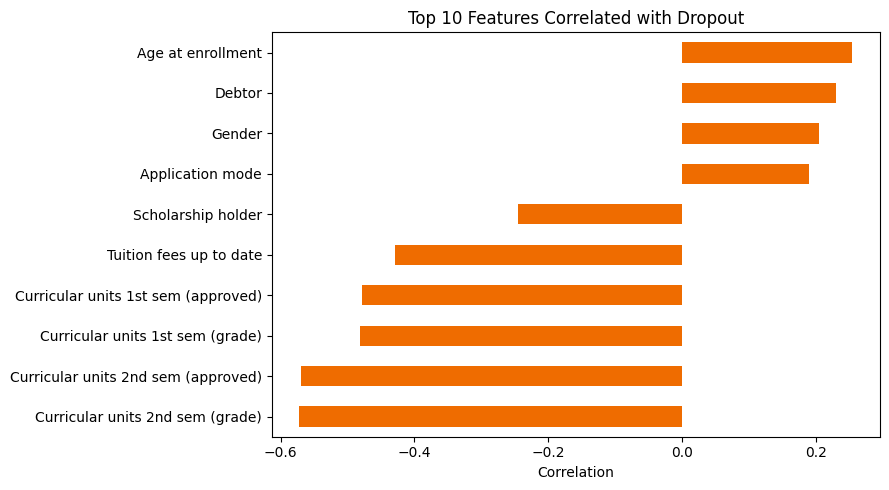

In [7]:
# Grade distributions
plt.figure(figsize=(9, 5))
plt.boxplot(
    [df[df.Dropout_Risk == 0][g1], df[df.Dropout_Risk == 1][g1],
     df[df.Dropout_Risk == 0][g2], df[df.Dropout_Risk == 1][g2]],
    labels=['1st Sem\nNot at risk', '1st Sem\nAt risk',
            '2nd Sem\nNot at risk', '2nd Sem\nAt risk'])
plt.title("Academic Performance and Dropout Risk")
plt.ylabel("Grade")
plt.grid(axis="y", alpha=0.2)
plt.show()

# Dropout rate by socioeconomic factors
factors = ["Scholarship holder", "Tuition fees up to date", "Debtor", "Gender"]
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, f in zip(axes, factors):
    (df.groupby(f)["Dropout_Risk"].mean() * 100).plot(kind="bar", ax=ax, color="#5c6bc0")
    ax.set_title(f"Dropout rate by\n{f}")
    ax.set_ylabel("Dropout rate (%)")
    ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

# Strongest correlations with dropout
corr = (df.drop(columns="Target").select_dtypes("number")
          .corr()["Dropout_Risk"].drop("Dropout_Risk"))
top = corr.reindex(corr.abs().sort_values(ascending=False).index)[:10]
plt.figure(figsize=(9, 5))
top.sort_values().plot(kind="barh", color="#ef6c00")
plt.title("Top 10 Features Correlated with Dropout")
plt.xlabel("Correlation")
plt.tight_layout()
plt.show()

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Training samples:", X_train.shape[0], "| Testing samples:", X_test.shape[0])
print("Dropout share  train: %.1f%%  test: %.1f%%" % (y_train.mean()*100, y_test.mean()*100))

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ("num", StandardScaler(), numerical_cols),
])

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000, random_state=42)),
])

model.fit(X_train, y_train)
print("\n✅ Model trained successfully")

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Predictions (first 20):", y_pred[:20])

prob_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Not At Risk Probability": (1 - y_prob).round(3),
    "At Risk Probability": y_prob.round(3),
})
display(prob_df.head(10))

Training samples: 3539 | Testing samples: 885
Dropout share  train: 32.1%  test: 32.1%

✅ Model trained successfully
Predictions (first 20): [0 0 1 0 1 0 1 1 0 1 1 0 1 0 0 0 1 0 0 0]


,Actual,Predicted,Not At Risk Probability,At Risk Probability
0,0,0,0.979,0.021
1,0,0,0.902,0.098
2,1,1,0.033,0.967
3,0,0,0.984,0.016
4,1,1,0.051,0.949
5,0,0,0.973,0.027
6,1,1,0.100,0.900
7,1,1,0.444,0.556
8,0,0,0.953,0.047
9,1,1,0.002,0.998


Accuracy : 0.8893
Precision: 0.8780
Recall   : 0.7606
F1-Score : 0.8151
ROC-AUC  : 0.9316

              precision    recall  f1-score   support

 Not At Risk       0.89      0.95      0.92       601
     At Risk       0.88      0.76      0.82       284

    accuracy                           0.89       885
   macro avg       0.89      0.86      0.87       885
weighted avg       0.89      0.89      0.89       885



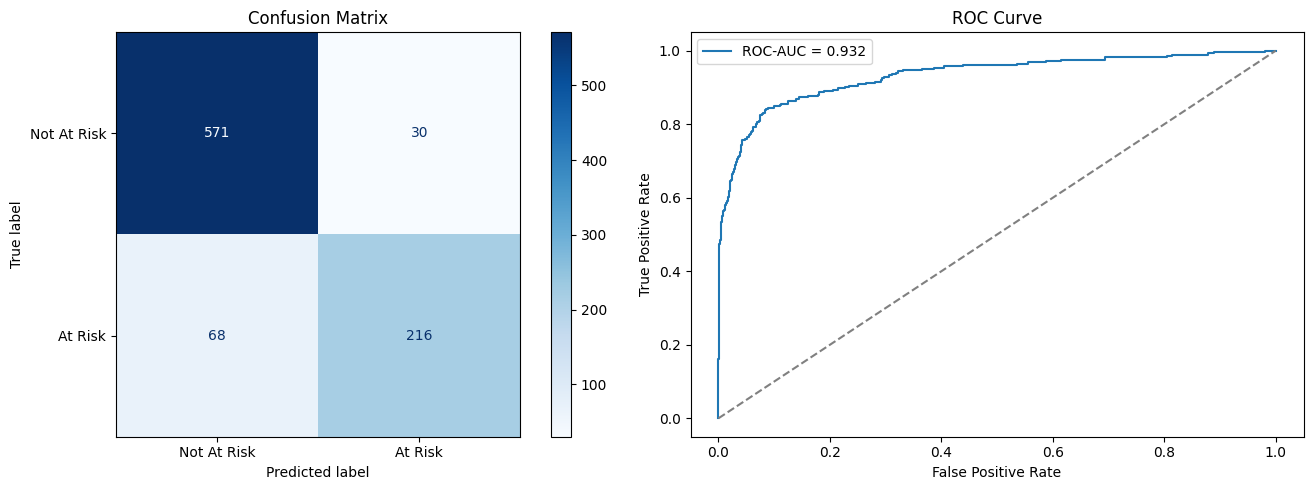

Error analysis
• False Positives (30): students flagged at risk who would NOT drop out -> some unnecessary support.
• False Negatives (68): real dropouts the model MISSED -> the costlier error for an early-warning system.

Effect of the decision threshold:


,Threshold,Precision,Recall,F1
0,0.3,0.771,0.856,0.811
1,0.4,0.844,0.803,0.823
2,0.5,0.878,0.761,0.815
3,0.6,0.909,0.701,0.791


In [9]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_curve)

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_prob)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}\n")
print(classification_report(y_test, y_pred, target_names=["Not At Risk", "At Risk"]))

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay(cm, display_labels=["Not At Risk", "At Risk"]).plot(ax=axes[0], cmap="Blues")
axes[0].set_title("Confusion Matrix")

fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")
axes[1].plot([0, 1], [0, 1], "--", color="gray")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()
plt.tight_layout()
plt.show()

print("Error analysis")
print(f"• False Positives ({fp}): students flagged at risk who would NOT drop out -> some unnecessary support.")
print(f"• False Negatives ({fn}): real dropouts the model MISSED -> the costlier error for an early-warning system.")

print("\nEffect of the decision threshold:")
rows = []
for t in [0.30, 0.40, 0.50, 0.60]:
    p = (y_prob >= t).astype(int)
    rows.append({"Threshold": t,
                 "Precision": round(precision_score(y_test, p), 3),
                 "Recall": round(recall_score(y_test, p), 3),
                 "F1": round(f1_score(y_test, p), 3)})
display(pd.DataFrame(rows))

In [10]:
metadata = {
    "features": X.columns.tolist(),
    "cat_options": {c: sorted(int(v) for v in X[c].unique()) for c in categorical_cols},
    "defaults": {
        **{c: int(X[c].mode()[0]) for c in categorical_cols},
        **{c: float(X[c].median()) for c in numerical_cols},
    },
    "metrics": {"accuracy": round(accuracy, 3), "precision": round(precision, 3),
                "recall": round(recall, 3), "f1": round(f1, 3), "roc_auc": round(roc_auc, 3)},
}

joblib.dump(model, "dropout_model.pkl")
with open("metadata.json", "w") as f:
    json.dump(metadata, f)

print("✅ Saved dropout_model.pkl and metadata.json")

✅ Saved dropout_model.pkl and metadata.json


In [11]:
%%writefile app.py
import json
import joblib
import pandas as pd
import streamlit as st

st.set_page_config(page_title="Student Dropout Risk Predictor", page_icon="🎓", layout="wide")


@st.cache_resource
def load_assets():
    model = joblib.load("dropout_model.pkl")
    with open("metadata.json") as f:
        meta = json.load(f)
    return model, meta


model, meta = load_assets()
options, defaults = meta["cat_options"], meta["defaults"]

# ---------- Readable labels (codes follow the dataset's data dictionary) ----------
YES_NO = {0: "No", 1: "Yes"}
GENDER = {0: "Female", 1: "Male"}
ATTENDANCE = {1: "Daytime", 0: "Evening"}
MARITAL = {1: "Single", 2: "Married", 3: "Widower", 4: "Divorced",
           5: "Facto union", 6: "Legally separated"}
COURSE = {33: "Biofuel Production Technologies", 171: "Animation & Multimedia Design",
          8014: "Social Service (evening)", 9003: "Agronomy", 9070: "Communication Design",
          9085: "Veterinary Nursing", 9119: "Informatics Engineering", 9130: "Equinculture",
          9147: "Management", 9238: "Social Service", 9254: "Tourism", 9500: "Nursing",
          9556: "Oral Hygiene", 9670: "Advertising & Marketing Management",
          9773: "Journalism & Communication", 9853: "Basic Education",
          9991: "Management (evening)"}

# ---------- Example students for quick testing ----------
def academic(enrolled, evaluated, approved, grade, without):
    d = {}
    for sem in ("1st", "2nd"):
        p = f"Curricular units {sem} sem"
        d.update({f"{p} (credited)": 0, f"{p} (enrolled)": enrolled,
                  f"{p} (evaluations)": evaluated, f"{p} (approved)": approved,
                  f"{p} (grade)": grade, f"{p} (without evaluations)": without})
    return d


SCENARIOS = {
    "Custom (manual entry)": {},
    "Strong student": {**academic(6, 6, 6, 15.0, 0), "Tuition fees up to date": 1,
                       "Debtor": 0, "Scholarship holder": 1, "Age at enrollment": 19},
    "Average student": {**academic(6, 7, 4, 12.0, 0), "Tuition fees up to date": 1,
                        "Debtor": 0, "Scholarship holder": 0, "Age at enrollment": 21},
    "Struggling student": {**academic(6, 8, 1, 8.0, 2), "Tuition fees up to date": 0,
                           "Debtor": 1, "Scholarship holder": 0, "Age at enrollment": 30},
}


def apply_scenario():
    for key, value in SCENARIOS[st.session_state["scenario"]].items():
        st.session_state[key] = value


# ---------- Input helpers ----------
row = {}


def select(label, col, labels=None):
    opts = options[col]
    idx = opts.index(defaults[col]) if defaults[col] in opts else 0
    fmt = (lambda v: labels.get(v, f"Code {v}")) if labels else (lambda v: f"Code {v}")
    row[col] = st.selectbox(label, opts, index=idx, format_func=fmt, key=col)


def int_input(label, col, lo, hi):
    val = int(min(max(defaults[col], lo), hi))
    row[col] = st.number_input(label, min_value=lo, max_value=hi, value=val, step=1, key=col)


def float_input(label, col, lo, hi, step=0.1):
    val = float(min(max(defaults[col], lo), hi))
    row[col] = st.number_input(label, min_value=float(lo), max_value=float(hi),
                               value=val, step=float(step), key=col)


# ---------- Sidebar ----------
with st.sidebar:
    st.header("⚙️ Quick Test Cases")
    st.selectbox("Load an example student", list(SCENARIOS), key="scenario",
                 on_change=apply_scenario)
    st.divider()
    st.subheader("📈 Model performance")
    m = meta["metrics"]
    st.write(f"Accuracy: **{m['accuracy']}**")
    st.write(f"Recall: **{m['recall']}**")
    st.write(f"ROC-AUC: **{m['roc_auc']}**")
    st.caption("Risk levels: Low < 40% · Medium 40–70% · High ≥ 70%")

# ---------- Header ----------
st.title("🎓 Student Dropout Risk Predictor")
st.write("An early-warning tool: enter a student's details to estimate their probability "
         "of dropping out and identify who may need extra support.")
st.divider()

# ---------- Student information ----------
st.header(" Student Information")
c1, c2, c3 = st.columns(3)
with c1:
    select("Marital status", "Marital status", MARITAL)
    select("Application mode", "Application mode")
    int_input("Application order", "Application order", 0, 9)
with c2:
    select("Course", "Course", COURSE)
    select("Attendance", "Daytime/evening attendance", ATTENDANCE)
    select("Previous qualification", "Previous qualification")
with c3:
    select("Nationality", "Nacionality")
    int_input("Age at enrollment", "Age at enrollment", 15, 70)
    select("Gender", "Gender", GENDER)

# ---------- Family ----------
st.header(" Family Background")
c1, c2, c3, c4 = st.columns(4)
with c1:
    select("Mother's qualification", "Mother's qualification")
with c2:
    select("Father's qualification", "Father's qualification")
with c3:
    select("Mother's occupation", "Mother's occupation")
with c4:
    select("Father's occupation", "Father's occupation")
st.caption("Codes follow the dataset's data dictionary.")

# ---------- Socioeconomic ----------
st.header(" Socioeconomic Status")
c1, c2, c3, c4, c5, c6 = st.columns(6)
with c1:
    select("Displaced", "Displaced", YES_NO)
with c2:
    select("Special needs", "Educational special needs", YES_NO)
with c3:
    select("Debtor", "Debtor", YES_NO)
with c4:
    select("Tuition up to date", "Tuition fees up to date", YES_NO)
with c5:
    select("Scholarship", "Scholarship holder", YES_NO)
with c6:
    select("International", "International", YES_NO)

# ---------- Academic ----------
st.header(" Academic Performance")
cols = st.columns(2)
for sem, col in zip(("1st", "2nd"), cols):
    p = f"Curricular units {sem} sem"
    with col:
        st.subheader(f"{sem} Semester")
        int_input("Credited units", f"{p} (credited)", 0, 60)
        int_input("Enrolled units", f"{p} (enrolled)", 0, 60)
        int_input("Evaluations", f"{p} (evaluations)", 0, 60)
        int_input("Approved units", f"{p} (approved)", 0, 60)
        float_input("Average grade (0–20)", f"{p} (grade)", 0.0, 20.0, 0.1)
        int_input("Without evaluations", f"{p} (without evaluations)", 0, 60)

# ---------- Economic ----------
st.header(" Economic Indicators")
c1, c2, c3 = st.columns(3)
with c1:
    float_input("Unemployment rate (%)", "Unemployment rate", 0.0, 40.0, 0.1)
with c2:
    float_input("Inflation rate (%)", "Inflation rate", -5.0, 15.0, 0.1)
with c3:
    float_input("GDP", "GDP", -10.0, 10.0, 0.01)

st.divider()

# ---------- Prediction ----------
if st.button("🔮 Predict Dropout Risk", type="primary", use_container_width=True):
    input_df = pd.DataFrame([{**defaults, **row}])[meta["features"]]
    probability = float(model.predict_proba(input_df)[0][1])
    prediction = int(model.predict(input_df)[0])

    if probability >= 0.70:
        level, icon, advice = "High Risk", "🔴", "Recommend immediate outreach: academic counselling, tutoring and financial-aid review."
    elif probability >= 0.40:
        level, icon, advice = "Medium Risk", "🟡", "Monitor closely and offer mentoring or study-support resources."
    else:
        level, icon, advice = "Low Risk", "🟢", "No immediate concern. Continue routine monitoring."

    st.subheader("📊 Prediction Result")
    r1, r2 = st.columns(2)
    r1.metric("Dropout Probability", f"{probability * 100:.2f}%")
    r2.metric("Risk Level", f"{icon} {level}")
    st.progress(probability)

    if prediction == 1:
        st.warning("The model predicts that this student is **at risk** of dropping out.")
    else:
        st.success("The model predicts that this student is **not at risk** of dropping out.")
    st.info(advice)

Writing app.py


In [12]:
import json, importlib

# ---------- 1. Write labels.py (official codes from the dataset paper) ----------
LABELS = r'''
MARITAL = dict(enumerate([
    "Single", "Married", "Widower", "Divorced", "Facto union", "Legally separated",
], start=1))

NATIONALITY = dict(enumerate([
    "Portuguese", "German", "Spanish", "Italian", "Dutch", "English", "Lithuanian",
    "Angolan", "Cape Verdean", "Guinean", "Mozambican", "Santomean", "Turkish",
    "Brazilian", "Romanian", "Moldovan", "Mexican", "Ukrainian", "Russian",
    "Cuban", "Colombian",
], start=1))

COURSE = dict(enumerate([
    "Biofuel Production Technologies", "Animation & Multimedia Design",
    "Social Service (evening)", "Agronomy", "Communication Design", "Veterinary Nursing",
    "Informatics Engineering", "Equinculture", "Management", "Social Service", "Tourism",
    "Nursing", "Oral Hygiene", "Advertising & Marketing Management",
    "Journalism & Communication", "Basic Education", "Management (evening)",
], start=1))

APP_MODE = dict(enumerate([
    "1st phase – general contingent", "Ordinance No. 612/93",
    "1st phase – special contingent (Azores)", "Holders of other higher courses",
    "Ordinance No. 854-B/99", "International student (bachelor)",
    "1st phase – special contingent (Madeira)", "2nd phase – general contingent",
    "3rd phase – general contingent", "Ordinance No. 533-A/99 b2 (different plan)",
    "Ordinance No. 533-A/99 b3 (other institution)", "Over 23 years old", "Transfer",
    "Change of course", "Technological specialization diploma holders",
    "Change of institution/course", "Short cycle diploma holders",
    "Change of institution/course (international)",
], start=1))

PREV_QUAL = dict(enumerate([
    "Secondary education", "Higher education – bachelor's degree", "Higher education – degree",
    "Higher education – master's degree", "Higher education – doctorate",
    "Frequency of higher education", "12th year – not completed", "11th year – not completed",
    "Other – 11th year of schooling", "10th year of schooling", "10th year – not completed",
    "Basic education 3rd cycle (9th–11th year)", "Basic education 2nd cycle (6th–8th year)",
    "Technological specialization course", "Higher education – degree (1st cycle)",
    "Professional higher technical course", "Higher education – master's degree (2nd cycle)",
], start=1))

QUALIFICATION = dict(enumerate([
    "Secondary education (12th year or equivalent)", "Higher education – bachelor's degree",
    "Higher education – degree", "Higher education – master's degree",
    "Higher education – doctorate", "Frequency of higher education",
    "12th year – not completed", "11th year – not completed", "7th year (old)",
    "Other – 11th year of schooling", "2nd year complementary high school course",
    "10th year of schooling", "General commerce course",
    "Basic education 3rd cycle (9th–11th year)", "Complementary high school course",
    "Technical-professional course", "Complementary high school course – not concluded",
    "7th year of schooling", "2nd cycle of the general high school course",
    "9th year – not completed", "8th year of schooling",
    "General course of administration and commerce", "Supplementary accounting and administration",
    "Unknown", "Cannot read or write", "Can read without a 4th year of schooling",
    "Basic education 1st cycle (4th/5th year)", "Basic education 2nd cycle (6th–8th year)",
    "Technological specialization course", "Higher education – degree (1st cycle)",
    "Specialized higher studies course", "Professional higher technical course",
    "Higher education – master's degree (2nd cycle)", "Higher education – doctorate (3rd cycle)",
], start=1))

OCCUPATION = dict(enumerate([
    "Student", "Legislative & executive bodies, directors and managers",
    "Specialists in intellectual & scientific activities", "Intermediate level technicians & professions",
    "Administrative staff", "Personal services, security & sales workers",
    "Farmers & skilled agriculture/fisheries/forestry workers",
    "Skilled industry, construction & craftsmen", "Machine operators & assembly workers",
    "Unskilled workers", "Armed forces professions", "Other situation", "Not specified",
    "Armed forces officers", "Armed forces sergeants", "Other armed forces personnel",
    "Directors of administrative & commercial services",
    "Hotel, catering, trade & other services directors",
    "Specialists in physical sciences, mathematics & engineering", "Health professionals",
    "Teachers", "Specialists in finance, accounting & administration",
    "Intermediate science & engineering technicians", "Intermediate health technicians",
    "Intermediate legal, social, sports & cultural technicians", "ICT technicians",
    "Office workers, secretaries & data processing operators",
    "Data, accounting, financial services & registry operators",
    "Other administrative support staff", "Personal service workers", "Sellers",
    "Personal care workers", "Protection & security personnel",
    "Market-oriented farmers & skilled agricultural workers",
    "Subsistence farmers, livestock keepers, fishermen & hunters",
    "Skilled construction workers (except electricians)",
    "Skilled metallurgy & metalworking workers", "Skilled electricity & electronics workers",
    "Food processing, woodworking & clothing workers", "Fixed plant & machine operators",
    "Assembly workers", "Vehicle drivers & mobile equipment operators",
    "Unskilled agriculture, animal production & forestry workers",
    "Unskilled extractive, construction, manufacturing & transport workers",
    "Meal preparation assistants", "Street vendors & street service providers",
], start=1))

assert (len(MARITAL), len(NATIONALITY), len(COURSE), len(APP_MODE),
        len(PREV_QUAL), len(QUALIFICATION), len(OCCUPATION)) == (6, 21, 17, 18, 17, 34, 46)
'''
open("labels.py", "w").write(LABELS)

# ---------- 2. Patch app.py ----------
src = open("app.py").read()
assert "def select(label, col, labels=None):" in src and "# ---------- Sidebar ----------" in src, \
    "❌ app.py is not the clean version. Re-run Cell 11 first, then run this cell."
assert "from labels import" not in src, \
    "❌ Already patched. Re-run Cell 11 to reset, then run this cell again."

NEW_BLOCK = '''from labels import MARITAL, COURSE, APP_MODE, PREV_QUAL, NATIONALITY, QUALIFICATION, OCCUPATION


def select(label, col, labels=None):
    opts = list(options[col])
    fmt = (lambda v: labels.get(v, f"Code {v}")) if labels else (lambda v: str(v))
    idx = opts.index(defaults[col]) if defaults[col] in opts else 0
    row[col] = st.selectbox(label, opts, index=idx, format_func=fmt, key=col)


'''
src = src.replace("# ---------- Sidebar ----------", NEW_BLOCK + "# ---------- Sidebar ----------", 1)

swaps = {
    'select("Application mode", "Application mode")': 'select("Application mode", "Application mode", APP_MODE)',
    'select("Previous qualification", "Previous qualification")': 'select("Previous qualification", "Previous qualification", PREV_QUAL)',
    'select("Nationality", "Nacionality")': 'select("Nationality", "Nacionality", NATIONALITY)',
    'select("Mother\'s qualification", "Mother\'s qualification")': 'select("Mother\'s qualification", "Mother\'s qualification", QUALIFICATION)',
    'select("Father\'s qualification", "Father\'s qualification")': 'select("Father\'s qualification", "Father\'s qualification", QUALIFICATION)',
    'select("Mother\'s occupation", "Mother\'s occupation")': 'select("Mother\'s occupation", "Mother\'s occupation", OCCUPATION)',
    'select("Father\'s occupation", "Father\'s occupation")': 'select("Father\'s occupation", "Father\'s occupation", OCCUPATION)',
}
for old, new in swaps.items():
    assert old in src, f"Could not find: {old}"
    src = src.replace(old, new)

src = src.replace('st.caption("Codes follow the dataset\'s data dictionary.")\n', '')
open("app.py", "w").write(src)
print("✅ labels.py written and app.py patched\n")

# ---------- 3. Verify against YOUR data ----------
import labels
importlib.reload(labels)
meta = json.load(open("metadata.json"))
checks = {
    "Marital status": labels.MARITAL, "Course": labels.COURSE,
    "Application mode": labels.APP_MODE, "Previous qualification": labels.PREV_QUAL,
    "Nacionality": labels.NATIONALITY, "Mother's qualification": labels.QUALIFICATION,
    "Father's qualification": labels.QUALIFICATION, "Mother's occupation": labels.OCCUPATION,
    "Father's occupation": labels.OCCUPATION,
}
print("Coverage check (every code in your data must have a name):")
for col, mapping in checks.items():
    missing = [v for v in meta["cat_options"][col] if v not in mapping]
    print(f"  {col}: {'all named ✅' if not missing else 'MISSING ' + str(missing)}")

print("\nSanity check (most common category in your data):")
for col in ["Marital status", "Course", "Application mode", "Previous qualification", "Nacionality"]:
    print(f"  {col}: {checks[col][df[col].value_counts().idxmax()]}")

✅ labels.py written and app.py patched

Coverage check (every code in your data must have a name):
  Marital status: all named ✅
  Course: all named ✅
  Application mode: all named ✅
  Previous qualification: all named ✅
  Nacionality: all named ✅
  Mother's qualification: all named ✅
  Father's qualification: all named ✅
  Mother's occupation: all named ✅
  Father's occupation: all named ✅

Sanity check (most common category in your data):
  Marital status: Single
  Course: Nursing
  Application mode: 1st phase – general contingent
  Previous qualification: Secondary education
  Nacionality: Portuguese


In [13]:
import json, joblib, re
import pandas as pd

model = joblib.load("dropout_model.pkl")
meta = json.load(open("metadata.json"))
defaults, features = meta["defaults"], meta["features"]

def academic(enrolled, evaluated, approved, grade, without):
    d = {}
    for sem in ("1st", "2nd"):
        p = f"Curricular units {sem} sem"
        d.update({f"{p} (credited)": 0, f"{p} (enrolled)": enrolled, f"{p} (evaluations)": evaluated,
                  f"{p} (approved)": approved, f"{p} (grade)": grade, f"{p} (without evaluations)": without})
    return d

def prob(acad, tuition, debtor, scholarship, age):
    row = {**defaults, **acad, "Tuition fees up to date": tuition, "Debtor": debtor,
           "Scholarship holder": scholarship, "Age at enrollment": age}
    return float(model.predict_proba(pd.DataFrame([row])[features])[0][1])

# ---- Search for a realistic profile whose risk is closest to 55% ----
best = None
for tuition in (1, 0):
    for approved in range(1, 6):
        for grade in [g / 2 for g in range(20, 31)]:          # grades 10.0 to 15.0
            p = prob(academic(6, 8, approved, grade, 0), tuition, 0, 0, 21)
            score = abs(p - 0.55) + (0.02 if tuition == 0 else 0)   # prefer fees paid
            if best is None or score < best[0]:
                best = (score, p, approved, grade, tuition)

_, p_mid, approved, grade, tuition = best
print(f"Borderline profile found: approved={approved}, grade={grade}, "
      f"tuition up to date={tuition} -> risk {p_mid*100:.1f}%")

# ---- Patch the sidebar example in app.py ----
src = open("app.py").read()
new_entry = (f'"Borderline student": {{**academic(6, 8, {approved}, {grade}, 0), '
             f'"Tuition fees up to date": {tuition}, "Debtor": 0, '
             f'"Scholarship holder": 0, "Age at enrollment": 21}},')
pattern = r'"(Average|Borderline) student": \{.*?"Age at enrollment": \d+\},'
assert re.search(pattern, src, re.S), "Could not find the example student entry in app.py"
src = re.sub(pattern, new_entry, src, count=1, flags=re.S)
open("app.py", "w").write(src)
print("✅ app.py updated\n")

# ---- Verify all three examples ----
print(f"Strong student     : {prob(academic(6,6,6,15.0,0), 1, 0, 1, 19)*100:.1f}%  (should be Low)")
print(f"Borderline student : {p_mid*100:.1f}%  (should be Medium)")
print(f"Struggling student : {prob(academic(6,8,1,8.0,2), 0, 1, 0, 30)*100:.1f}%  (should be High)")

Borderline profile found: approved=2, grade=11.0, tuition up to date=1 -> risk 55.0%
✅ app.py updated

Strong student     : 1.9%  (should be Low)
Borderline student : 55.0%  (should be Medium)
Struggling student : 98.0%  (should be High)


In [14]:
import sklearn
with open("requirements.txt", "w") as f:
    f.write(f"streamlit\npandas\nnumpy\nscikit-learn=={sklearn.__version__}\njoblib\n")
print(open("requirements.txt").read())

streamlit
pandas
numpy
scikit-learn==1.6.1
joblib



In [19]:
%%writefile README.md
# 🎓 Student Dropout Prediction

A Logistic Regression model that predicts whether a student is at risk of dropping out,
with a Streamlit app that returns a dropout probability and a risk level (Low / Medium / High).

**Live app:** <LIVE_APP_URL>

## Problem
Identify students who may need extra support early, using academic, demographic,
socioeconomic and enrollment data.

## Data
Predict Students' Dropout and Academic Success dataset (4,424 students, 36 features).
Target: `Dropout` = 1, `Enrolled` / `Graduate` = 0. About 32.1% of students dropped out.

## Method
1. Cleaning (missing values, duplicates) and binary target creation
2. Exploratory analysis of grades, scholarship, tuition status and debt
3. Pipeline: One-Hot Encoding + Standard Scaling + Logistic Regression
4. Evaluation: accuracy, precision, recall, F1, ROC-AUC, confusion matrix

## Results

| Metric    | Score |
|-----------|-------|
| Accuracy  | 0.889 |
| Precision | 0.878 |
| Recall    | 0.761 |
| F1-score  | 0.815 |
| ROC-AUC   | 0.932 |

**Interpretation:** The model correctly identifies about 76% of students who go on to
drop out (recall), and 88% of the students it flags are genuine dropouts (precision).
For an early-warning system, missed dropouts (false negatives) are the costlier error,
so recall is the metric to watch.

## Key findings
- **Academic performance is the strongest signal.** Students who dropped out averaged a grade
  of 7.26 in the 1st semester and 5.90 in the 2nd, versus 12.24 and 12.28 for other students.
  They also passed far fewer curricular units (2.55 and 1.94 per semester, versus 5.73 and 5.62).
  Second-semester grades and approved units had the strongest correlation with dropout.
- **Financial factors matter.** 86.6% of students whose tuition fees were not up to date dropped
  out, versus 24.7% of those who were. Debtors dropped out at 62.0% (versus 28.3%), while
  scholarship holders dropped out far less (12.2% versus 38.7%).
- **Demographics add smaller effects.** Male students dropped out more often than female
  students (45.1% versus 25.1%), and older age at enrollment was positively associated with dropout.

These are associations, not proven causes.

## Risk levels used in the app

| Dropout probability | Risk level |
|---------------------|------------|
| Below 40%           | Low        |
| 40% to 70%          | Medium     |
| 70% or above        | High       |

## Application features
- Readable dropdowns for course, nationality, qualifications and occupations
- Built-in example students (strong, borderline, struggling) for quick testing
- Dropout probability, risk level and a suggested action for each student

## Project files
- `app.py`: Streamlit application
- `labels.py`: readable names for the dataset's numeric category codes
- `dropout_model.pkl`: trained Logistic Regression pipeline
- `metadata.json`: feature list, dropdown options and model metrics
- `requirements.txt`: dependencies
- `Student_Dropout_Prediction.ipynb`: full notebook (EDA, training, evaluation)

## Run locally

    pip install -r requirements.txt
    streamlit run app.py

## Use case
An early-warning system: advisors enter student data, and students with a high
dropout probability are flagged early for counselling, tutoring or financial support.

## Limitations
- The model is trained on data from a single institution, so results may not transfer elsewhere.
- Predictions are probabilities, not certainties, and should support human decisions, not replace them.

## Author
Saira Batool

## Data source
Realinho, V., Machado, J., Baptista, L., Martins, M.V. (2022). Predicting Student
Dropout and Academic Success. Data, 7(11), 146. Dataset on the UCI Machine Learning Repository.

Overwriting README.md


In [20]:
import subprocess, time, re, os

# Stop anything left over from earlier runs
subprocess.run('pkill -f "[s]treamlit run"; pkill -f "[c]loudflared"', shell=True)

# Download cloudflared (free quick tunnel, no password page)
if not os.path.exists("cloudflared"):
    subprocess.run("wget -q -O cloudflared https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 && chmod +x cloudflared",
                   shell=True, check=True)

# Start Streamlit once
subprocess.Popen(
    ["streamlit", "run", "app.py", "--server.port", "8501", "--server.headless", "true",
     "--server.enableCORS", "false", "--server.enableXsrfProtection", "false"],
    stdout=open("streamlit.log", "w"), stderr=subprocess.STDOUT)
time.sleep(6)

# Start the tunnel
subprocess.Popen(["./cloudflared", "tunnel", "--url", "http://localhost:8501", "--no-autoupdate"],
                 stdout=open("cloudflared.log", "w"), stderr=subprocess.STDOUT)

url = None
for _ in range(30):
    time.sleep(2)
    m = re.search(r"https://[-a-z0-9]+\.trycloudflare\.com", open("cloudflared.log").read())
    if m:
        url = m.group(0)
        break

print("🌐 Open your app:", url if url else "Tunnel not ready. Run: !cat cloudflared.log streamlit.log")

🌐 Open your app: https://married-served-ideas-courier.trycloudflare.com


In [22]:
!zip -q dropout_project.zip app.py labels.py dropout_model.pkl metadata.json requirements.txt README.md
from google.colab import files
files.download("dropout_project.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>